# Rapport d'étude de SAM 3 - Tom LE BER (22308482) & Tony PEROTTINO (22303877)

---

## 0. Méthode de lancement de la V4

Afin de faire tourner ce Google Colab (et plus particulièrement SAM 3), il est nécessaire de disposer d'un token **Hugging Face**.  
De plus, l'installation de `SAM 3` et de ses dépendances nécessite une précédure de lancement légèrement différente des autres Google Colab.

Au premier lancement, allez sur `Runtime`, puis `Change runtime type`, puis `T4 GPU`.  
Ceci permet au Google Colab de tourner en mode GPU. Cette étape est essentielle pour le bon fonctionnement du Google Colab.

Afin de faire fonctionner ce Google Colab, veuillez procéder de la manière suivante :  
1. Lancez la partie `I. Installation des bibliothèques` (vous allez obtenir des erreurs, c'est normal)
2. Une fois l'execution terminée, cliquez sur :
    - `Runtime` dans le menu en haut à gauche
    - Puis `Restart session and run all`

Vous aurez besoin d'entrer deux fois votre token Hugging Face, une fois pour chaque lancement de la partie `I`.

In [1]:
from getpass import getpass

# Raccourcis pour token Hugging Face :
    # Il faut avoir obtenu l'accès Hugging Face au modèle : facebook/sam-3d-body-dinov3
HUGGING_FACE_TOKEN = getpass("Token Hugging Face : ").strip()

# Raccourcis pour les importations vidéo :
IMPORT_TYPE = 0     # 0 = Depuis le GitHub.
VIDEO_GIT_INDEX = 1 # 1 = Première vidéo sur le GitHub.

# Raccourcis pour les prompts SAM 3 (ce Google Colab choisit automatiquement le prompt avec la meilleure performance en fonction de la vidéo d'entrée) :
    # Si aucun prompt n'est fourni, le programme se lancera sur 8 prompts par défaut (et choisira le meilleur d'entre-eux).
SAM3_TEXT_PROMPTS = [
    "person",
    "human",
    "person standing",
    "person on the floor",
    "person near a pole",
    "pole dancer",
    "woman doing pole dance",
    "man doing pole dance"
]

Token Hugging Face : ··········


---

## I. Installation des bibliothèques

### 1. Vérification de l'environnement d'exécution

In [2]:
import os
import sys
import subprocess

print(f"Version Python : {sys.version}")
print(f"Exécutable Python : {sys.executable}")

# Vérification GPU :
try:
    gpu_info = subprocess.check_output(["nvidia-smi"], text=True)
    print(f"nvidia-smi détecté avec succès.")
except Exception:
    gpu_info = None
    print(f"ATTENTION : nvidia-smi introuvable. Un GPU CUDA est fortement recommandée pour SAM 3.")

if sys.version_info < (3, 12):
    raise RuntimeError(f"Le repo officiel de SAM 3 demande Python 3.12+.")

Version Python : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Exécutable Python : /usr/bin/python3
nvidia-smi détecté avec succès.


#### A. Authentification Hugging Face

In [3]:
%pip -q install huggingface_hub gdown

In [4]:
from getpass import getpass
from huggingface_hub import login, whoami

try:
    if not isinstance(HUGGING_FACE_TOKEN, str):
        raise TypeError("HUGGING_FACE_TOKEN doit être une chaîne")

    HF_TOKEN = HUGGING_FACE_TOKEN.strip()
    if not HF_TOKEN:
        raise ValueError("HUGGING_FACE_TOKEN ne doit pas être vide")

except (NameError, TypeError, ValueError):
    HF_TOKEN = getpass("Token Hugging Face : ").strip()

if len(HF_TOKEN) == 0:
    raise RuntimeError("Le token Hugging Face est vide.")

login(token=HF_TOKEN, add_to_git_credential=False)
print("Authentification Hugging Face effectuée.")
print(whoami())

Authentification Hugging Face effectuée.
{'type': 'user', 'id': '69cb6b70209141131a40ccf8', 'name': 'tominien', 'fullname': 'Tom Le Ber', 'email': 'tom.leber.toulouse@gmail.com', 'emailVerified': True, 'canPay': False, 'billingMode': 'prepaid', 'periodEnd': 1777593600, 'isPro': False, 'avatarUrl': '/avatars/abbaa66f4e60ad1ad6aebd480034b834.svg', 'orgs': [], 'auth': {'type': 'access_token', 'accessToken': {'displayName': 'ter_irit', 'role': 'read', 'createdAt': '2026-03-31T06:55:29.307Z'}}}


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


#### B. Clonage et installation de `SAM 3`

In [5]:
import os
import sys

print("Python courant :", sys.executable)
print("Version Python :", sys.version)

# Dépendances minimales utiles au notebook SAM 3 :
%pip install -q "numpy>=1.26,<2" "opencv-python==4.11.0.86" "decord" "einops" "pycocotools"

# Clonage propre du dépôt :
!rm -rf /content/sam3_repo
!git clone https://github.com/facebookresearch/sam3.git /content/sam3_repo

# Installation editable dans le noyau courant :
%pip install -q -e /content/sam3_repo

print("Installation terminée.")
print("Redémarre maintenant manuellement le runtime, puis relance depuis le début du notebook.")

Python courant : /usr/bin/python3
Version Python : 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Cloning into '/content/sam3_repo'...
remote: Enumerating objects: 1072, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 1072 (delta 5), reused 6 (delta 4), pack-reused 1058 (from 2)
Receiving objects: 100% (1072/1072), 60.36 MiB | 22.54 MiB/s, done.
Resolving deltas: 100% (258/258), done.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for sam3 (pyproject.toml) ... done
Installation terminée.
Redémarre maintenant manuellement le runtime, puis relance depuis le début du notebook.


### 2. Vérification de l'installation

In [6]:
import importlib
import torch

modules_to_test = [
    "numpy",
    "cv2",
    "torch",
    "huggingface_hub",
    "decord",
    "einops",
    "sam3",
]

for name in modules_to_test:
    try:
        mod = importlib.import_module(name)
        version = getattr(mod, "__version__", "version inconnue")
        print(f"[OK] {name} | version = {version}")
    except Exception as e:
        print(f"[ERREUR] {name} | {repr(e)}")

print("\nCUDA disponible :", torch.cuda.is_available())

from sam3.model_builder import build_sam3_image_model, build_sam3_video_predictor
from sam3.model.sam3_image_processor import Sam3Processor

print("Imports principaux SAM 3 effectués avec succès.")

[OK] numpy | version = 1.26.4
[OK] cv2 | version = 4.11.0
[OK] torch | version = 2.10.0+cu128
[OK] huggingface_hub | version = 1.10.1
[OK] decord | version = 0.6.0
[OK] einops | version = 0.8.2


/content/sam3_repo/sam3/model/model_misc.py:70: UserWarning: Flash Attention is disabled as it requires a GPU with Ampere (8.0) CUDA capability.
  OLD_GPU, USE_FLASH_ATTN, MATH_KERNEL_ON = get_sdpa_settings()


[OK] sam3 | version = 0.1.0

CUDA disponible : True
Imports principaux SAM 3 effectués avec succès.


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


---

## II. Chargement des données et préparation des dossiers

### 1. Montage du GitHub et création des chemins

In [7]:
import os
import shutil

GITHUB_REPOSITORY_DIR = "/content/stage-midl-2_repo"
WORKING_DIR = "/content/working_dir"

# Dossiers de travail :
FRAMES_DIRECTORY  = os.path.join(WORKING_DIR, "frames")
MASKS_DIRECTORY   = os.path.join(WORKING_DIR, "masks")
RESULTS_DIRECTORY = os.path.join(WORKING_DIR, "results")

# Fichiers principaux :
VIDEO_PATH          = os.path.join(WORKING_DIR, "video.mp4")
NEW_BACKGROUND_PATH = os.path.join(WORKING_DIR, "new_background.png")
ANNOTATIONS_PATH    = os.path.join(WORKING_DIR, "annotations.csv")

os.makedirs(WORKING_DIR, exist_ok=True)
os.makedirs(FRAMES_DIRECTORY, exist_ok=True)
os.makedirs(MASKS_DIRECTORY, exist_ok=True)
os.makedirs(RESULTS_DIRECTORY, exist_ok=True)

print(f"Dossier de travail : {WORKING_DIR}")
print(f"Dossier des frames : {FRAMES_DIRECTORY}")
print(f"Dossier des masques : {MASKS_DIRECTORY}")
print(f"Dossier des résultats : {RESULTS_DIRECTORY}")

Dossier de travail : /content/working_dir
Dossier des frames : /content/working_dir/frames
Dossier des masques : /content/working_dir/masks
Dossier des résultats : /content/working_dir/results


#### A. Montage du GitHub

In [8]:
if not os.path.exists(GITHUB_REPOSITORY_DIR):
    !git clone https://github.com/tominien/sports-digital-twin-irit-research-internship.git "{GITHUB_REPOSITORY_DIR}"
else:
    print("Le dépôt GitHub du projet existe déjà.")

Cloning into '/content/stage-midl-2_repo'...
remote: Enumerating objects: 1486, done.
remote: Total 1486 (delta 0), reused 0 (delta 0), pack-reused 1486 (from 2)
Receiving objects: 100% (1486/1486), 3.45 GiB | 34.49 MiB/s, done.
Resolving deltas: 100% (55/55), done.


#### B. Fonctions de chargement des ressources

In [9]:
import subprocess
import gdown
from PIL import Image
from google.colab import files, output

def reset_working_directories():
    """
    Réinitialise les dossiers de travail utiles au pipeline courant.
    """
    shutil.rmtree(FRAMES_DIRECTORY, ignore_errors=True)
    shutil.rmtree(MASKS_DIRECTORY, ignore_errors=True)
    shutil.rmtree(RESULTS_DIRECTORY, ignore_errors=True)

    os.makedirs(FRAMES_DIRECTORY, exist_ok=True)
    os.makedirs(MASKS_DIRECTORY, exist_ok=True)
    os.makedirs(RESULTS_DIRECTORY, exist_ok=True)

def create_default_background_from_video(video_path: str = VIDEO_PATH,new_background_path: str = NEW_BACKGROUND_PATH):
    """
    Crée une image blanche (PNG) aux dimensions de la vidéo originale.
    """
    if not os.path.isfile(video_path):
        raise ValueError("Vidéo source manquante pour créer le fond par défaut.")

    cmd = [
        "ffprobe", "-v", "error",
        "-select_streams", "v:0",
        "-show_entries", "stream=width,height",
        "-of", "csv=p=0:s=x",
        video_path
    ]

    try:
        dims = subprocess.check_output(cmd, text=True).strip()
        w_str, h_str = dims.split("x")
        w, h = int(w_str), int(h_str)
    except Exception as e:
        raise ValueError(f"Impossible de lire les dimensions de la vidéo : {e}")

    img = Image.new("RGB", (w, h), (255, 255, 255))
    img.save(new_background_path, format="PNG")
    print(f"Fond par défaut créé dans : {new_background_path}")

def download_file_from_drive(file_url: str, file_colab_path: str):
    """
    Télécharge un fichier Google Drive à partir d'un lien de partage.
    """
    if "/folders/" in file_url:
        raise ValueError("Lien Google Drive détecté comme un dossier. Un lien de fichier est attendu.")

    res = gdown.download(
        url=file_url,
        output=file_colab_path,
        quiet=False,
        fuzzy=True
    )

    if not res or not os.path.exists(file_colab_path):
        raise ValueError("Téléchargement Google Drive échoué.")

def load_resources_github(video_git_index: int = 1):
    """
    Charge les ressources depuis le dépôt GitHub du projet.
    """
    source_dir = os.path.join(GITHUB_REPOSITORY_DIR, "data", f"video_{video_git_index}")

    source_video = os.path.join(source_dir, "video.mp4")
    source_background = os.path.join(source_dir, "new_background.png")
    source_annotations = os.path.join(source_dir, "annotations.csv")

    if not os.path.exists(source_video):
        raise FileNotFoundError(f"Vidéo introuvable : {source_video}")

    shutil.copy(source_video, VIDEO_PATH)
    print(f"Vidéo copiée dans : {VIDEO_PATH}")

    if os.path.exists(source_background):
        shutil.copy(source_background, NEW_BACKGROUND_PATH)
        print(f"Fond copié dans : {NEW_BACKGROUND_PATH}")
    else:
        create_default_background_from_video()

    if os.path.exists(source_annotations):
        shutil.copy(source_annotations, ANNOTATIONS_PATH)
        print(f"Annotations copiées dans : {ANNOTATIONS_PATH}")
    else:
        print("WARNING : annotations.csv introuvable dans le dépôt.")

def load_resources_local():
    """
    Charge les ressources depuis l'explorateur local.
    """
    print("\nChoisissez la vidéo d'entrée (.mp4) :")
    uploaded_video = files.upload()

    if len(uploaded_video) == 0:
        raise RuntimeError("Aucune vidéo n'a été envoyée.")

    temp_video = list(uploaded_video.keys())[0]
    shutil.copy(temp_video, VIDEO_PATH)
    os.remove(temp_video)
    output.clear()
    print(f"Vidéo copiée dans : {VIDEO_PATH}")

    print("\nChoisissez le nouveau fond (.png) pour la recontruction vidéo (optionnel) :")
    uploaded_bg = files.upload()

    if len(uploaded_bg) > 0:
        temp_bg = list(uploaded_bg.keys())[0]
        shutil.copy(temp_bg, NEW_BACKGROUND_PATH)
        os.remove(temp_bg)
        output.clear()
        print(f"Fond copié dans : {NEW_BACKGROUND_PATH}")
    else:
        create_default_background_from_video()

    print("\nChoisissez le fichier d'annotations (.csv) pour l'évaluation vidéo (optionnel) :")
    uploaded_csv = files.upload()

    if len(uploaded_csv) > 0:
        temp_csv = list(uploaded_csv.keys())[0]
        shutil.copy(temp_csv, ANNOTATIONS_PATH)
        os.remove(temp_csv)
        output.clear()
        print(f"Annotations copiées dans : {ANNOTATIONS_PATH}")
    else:
        print("Aucune annotation fournie.")

def load_resources_drive():
    """
    Charge les ressources via liens Google Drive.
    """
    video_url = input("\nLien de téléchargement de la vidéo originale sur Google Drive : ").strip()
    if len(video_url) == 0:
        raise RuntimeError("Aucun lien vidéo fourni.")

    download_file_from_drive(video_url, VIDEO_PATH)
    print(f"Vidéo copiée dans : {VIDEO_PATH}")

    bg_url = input("\nLien de téléchargement du nouveau fond sur Google Drive (optionnel) : ").strip()
    if len(bg_url) > 0:
        download_file_from_drive(bg_url, NEW_BACKGROUND_PATH)
        print(f"Fond copié dans : {NEW_BACKGROUND_PATH}")
    else:
        print("Aucun fond fourni.")
        create_default_background_from_video()

    ann_url = input("Lien de téléchargement du CSV d'annotations sur Google Drive (optionnel) : ").strip()
    if len(ann_url) > 0:
        download_file_from_drive(ann_url, ANNOTATIONS_PATH)
        print(f"Annotations copiées dans : {ANNOTATIONS_PATH}")
    else:
        print("Aucune annotation fournie.")

def load_resources(import_type: int):
    """
    Charge les ressources selon le mode choisi.
      0 = GitHub
      1 = local
      2 = Google Drive
    """
    reset_working_directories()

    if import_type == 0:
        try:
            if not isinstance(VIDEO_GIT_INDEX, int):
                raise TypeError("VIDEO_GIT_INDEX doit être un entier")
            video_git_index = VIDEO_GIT_INDEX

        except (NameError, TypeError, ValueError):
            video_git_index = int(input("\nIndice de la vidéo dans le dossier 'data' sur GitHub : "))

        load_resources_github(video_git_index=video_git_index)

    elif import_type == 1:
        load_resources_local()

    elif import_type == 2:
        load_resources_drive()

    else:
        raise ValueError("Type de chargement invalide.")

#### C. Chargement des ressources

In [10]:
try:
    if not isinstance(IMPORT_TYPE, int):
        raise TypeError("IMPORT_TYPE doit être un entier")
    import_type = IMPORT_TYPE

except (NameError, TypeError, ValueError):
    import_type = int(input("Entrez le type de la vidéo étudiée :\n\t0 = Upload depuis GitHub\n\t1 = Upload en local (depuis l'explorateur)\n\t2 = Upload depuis un lien Google Drive\n"))

load_resources(import_type=import_type)

if not os.path.isfile(VIDEO_PATH):
    raise RuntimeError("La vidéo d'entrée n'a pas été correctement chargée.")

if not os.path.isfile(NEW_BACKGROUND_PATH):
    raise RuntimeError("Le fond de remplacement est introuvable.")

print(f"\nVidéo prête : {VIDEO_PATH}")
print(f"Fond prêt  : {NEW_BACKGROUND_PATH}")

if os.path.exists(ANNOTATIONS_PATH):
    print(f"Annotations : {ANNOTATIONS_PATH}")
else:
    print("Annotations : Absentes.")

Vidéo copiée dans : /content/working_dir/video.mp4
Fond copié dans : /content/working_dir/new_background.png
Annotations copiées dans : /content/working_dir/annotations.csv

Vidéo prête : /content/working_dir/video.mp4
Fond prêt  : /content/working_dir/new_background.png
Annotations : /content/working_dir/annotations.csv


### 2. Extraction en frames de la vidéo

In [11]:
import glob

# Nettoyage préalable du dossier des frames :
shutil.rmtree(FRAMES_DIRECTORY, ignore_errors=True)
os.makedirs(FRAMES_DIRECTORY, exist_ok=True)

# Extraction des frames :
!ffmpeg -i "{VIDEO_PATH}" "{FRAMES_DIRECTORY}/%05d.png" -hide_banner -loglevel error -nostdin

# Vérification :
extracted_frames = sorted(
    glob.glob(os.path.join(FRAMES_DIRECTORY, "*.png")) +
    glob.glob(os.path.join(FRAMES_DIRECTORY, "*.jpg")) +
    glob.glob(os.path.join(FRAMES_DIRECTORY, "*.jpeg"))
)

if len(extracted_frames) == 0:
    raise RuntimeError("Aucune frame n'a été extraite de la vidéo.")

print(f"Nombre de frames extraites : {len(extracted_frames)}")
print(f"Première frame : {os.path.basename(extracted_frames[0])}")
print(f"Dernière frame : {os.path.basename(extracted_frames[-1])}")

Nombre de frames extraites : 1329
Première frame : 00001.png
Dernière frame : 01329.png


In [12]:
import shutil

SAM3_PROXY_FRAMES_DIR = os.path.join(WORKING_DIR, "sam3_proxy_frames")
SAM3_TMP_CHUNK_DIR = os.path.join(WORKING_DIR, "sam3_tmp_chunk")

# Réglage mémoire principal pour T4 :
SAM3_PROXY_MAX_HEIGHT = 720

shutil.rmtree(SAM3_PROXY_FRAMES_DIR, ignore_errors=True)
os.makedirs(SAM3_PROXY_FRAMES_DIR, exist_ok=True)

# Création d'une version JPEG réduite de la vidéo uniquement pour SAM 3 :
!ffmpeg -i "{VIDEO_PATH}" \
    -vf "scale=-2:{SAM3_PROXY_MAX_HEIGHT}:force_original_aspect_ratio=decrease" \
    -q:v 2 \
    "{SAM3_PROXY_FRAMES_DIR}/%05d.jpg" \
    -hide_banner -loglevel error -nostdin

sam3_proxy_frame_paths = sorted(glob.glob(os.path.join(SAM3_PROXY_FRAMES_DIR, "*.jpg")))

if len(sam3_proxy_frame_paths) == 0:
    raise RuntimeError("Aucune frame proxy JPEG n'a été générée pour SAM 3.")

print(f"Frames proxy SAM 3 générées : {len(sam3_proxy_frame_paths)}")
print(f"Première frame proxy : {os.path.basename(sam3_proxy_frame_paths[0])}")
print(f"Dernière frame proxy  : {os.path.basename(sam3_proxy_frame_paths[-1])}")

Frames proxy SAM 3 générées : 1329
Première frame proxy : 00001.jpg
Dernière frame proxy  : 01329.jpg


---

## III. Calibration de `SAM 3` sur images

### 1. Chargement des frames et définition des phrases de prompts

In [13]:
import os
import glob
import cv2
import torch
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

# Indexation simple des frames disponibles :
frame_paths_all = sorted(
    glob.glob(os.path.join(FRAMES_DIRECTORY, "*.png")) +
    glob.glob(os.path.join(FRAMES_DIRECTORY, "*.jpg")) +
    glob.glob(os.path.join(FRAMES_DIRECTORY, "*.jpeg"))
)

if len(frame_paths_all) == 0:
    raise ValueError(f"Aucune frame trouvée dans : {FRAMES_DIRECTORY}")

frame_names_all = [os.path.basename(p) for p in frame_paths_all]

print(f"Nombre total de frames extraites : {len(frame_paths_all)}")
print(f"Première frame : {frame_names_all[0]}")
print(f"Dernière frame  : {frame_names_all[-1]}")

# Paramètres SAM 3 (image) :
SAM3_IMAGE_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SAM3_IMAGE_RESOLUTION = 1008
SAM3_IMAGE_CONFIDENCE_THRESHOLD = 0.45

# Frame utilisée pour choisir le meilleur prompt texte :
PROMPT_TEST_FRAME_INDEX = 0

# Candidats de prompts texte :
DEFAULT_SAM3_TEXT_PROMPTS = [
    "person",
    "human",
    "person standing",
    "person on the floor",
    "person near a pole",
    "pole dancer",
    "woman doing pole dance",
    "man doing pole dance"
]

try:
    if not isinstance(SAM3_TEXT_PROMPTS, list):
        raise TypeError("SAM3_TEXT_PROMPTS doit être une liste")
    if not all(isinstance(x, str) for x in SAM3_TEXT_PROMPTS):
        raise TypeError("Tous les éléments de SAM3_TEXT_PROMPTS doivent être des chaînes")
    sam3_text_prompts = SAM3_TEXT_PROMPTS

except (NameError, TypeError):
    sam3_text_prompts = DEFAULT_SAM3_TEXT_PROMPTS.copy()

if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True

print(f"Device utilisé : {SAM3_IMAGE_DEVICE}")

Nombre total de frames extraites : 1329
Première frame : 00001.png
Dernière frame  : 01329.png
Device utilisé : cuda


### 2. Chargement du modèle image

In [14]:
from sam3.model_builder import build_sam3_image_model
from sam3.model.sam3_image_processor import Sam3Processor

sam3_image_model = build_sam3_image_model()

sam3_image_processor = Sam3Processor(
    model=sam3_image_model,
    resolution=SAM3_IMAGE_RESOLUTION,
    device=SAM3_IMAGE_DEVICE,
    confidence_threshold=SAM3_IMAGE_CONFIDENCE_THRESHOLD,
)

print("Modèle SAM 3 (image) chargé avec succès.")

config.json: 0.00B [00:00, ?B/s]

sam3.pt:   0%|          | 0.00/3.45G [00:00<?, ?B/s]

Modèle SAM 3 (image) chargé avec succès.


### 3. Fonctions utilitaires de test sur une frame

In [15]:
def to_numpy(x):
    """
    Convertit en numpy si nécessaire.
    Gère explicitement le cas des tenseurs bfloat16.
    """
    if torch.is_tensor(x):
        x = x.detach().cpu()

        # NumPy ne supporte pas directement bfloat16 :
        if x.dtype == torch.bfloat16:
            x = x.float()

        return x.numpy()

    return np.asarray(x)

def normalize_binary_mask(mask):
    """
    Convertit un masque SAM 3 en masque binaire booléen [H, W].
    """
    mask = to_numpy(mask)
    mask = np.squeeze(mask)

    if mask.ndim != 2:
        raise ValueError(f"Masque inattendu, shape reçue : {mask.shape}")

    if mask.dtype == np.bool_:
        return mask

    if np.issubdtype(mask.dtype, np.floating):
        return mask > 0.0

    return mask > 0

def overlay_mask_on_rgb(image_rgb, mask_bool, alpha=0.45):
    """
    Superpose un masque binaire à une image RGB.
    """
    out = image_rgb.copy()
    out[mask_bool] = (
        (1.0 - alpha) * out[mask_bool] +
        alpha * np.array([255, 255, 255], dtype=np.float32)
    ).astype(np.uint8)
    return out

def run_sam3_on_image(img_path: str, prompt: str):
    """
    Applique SAM 3 (image) à une image unique avec un prompt texte.

    Retourne :
      - frame
      - prompt
      - has_person
      - best_mask
      - best_box
      - best_score
      - masks
      - boxes
      - scores
    """
    image_pil = Image.open(img_path).convert("RGB")

    with torch.inference_mode(), torch.autocast(
        "cuda",
        dtype=torch.bfloat16,
        enabled=torch.cuda.is_available()
    ):
        state = sam3_image_processor.set_image(image_pil)
        output = sam3_image_processor.set_text_prompt(
            state=state,
            prompt=prompt,
        )

    masks = to_numpy(output["masks"])
    boxes = to_numpy(output["boxes"])
    scores = to_numpy(output["scores"]).reshape(-1)

    if scores.size == 0:
        return {
            "frame": os.path.basename(img_path),
            "prompt": prompt,
            "has_person": False,
            "best_mask": None,
            "best_box": None,
            "best_score": None,
            "masks": None,
            "boxes": None,
            "scores": None,
        }

    best_idx = int(np.argmax(scores))
    best_mask = normalize_binary_mask(masks[best_idx])

    best_box = None
    if boxes is not None and len(boxes) > best_idx:
        best_box = to_numpy(boxes[best_idx]).tolist()

    return {
        "frame": os.path.basename(img_path),
        "prompt": prompt,
        "has_person": True,
        "best_mask": best_mask,
        "best_box": best_box,
        "best_score": float(scores[best_idx]),
        "masks": masks,
        "boxes": boxes,
        "scores": scores,
    }

def visualize_sam3_prompt_results(img_path: str, prompt_results: list[dict]):
    """
    Affiche une comparaison visuelle des prompts texte testés sur une même frame.
    """
    image_rgb = np.array(Image.open(img_path).convert("RGB"))

    n = len(prompt_results)
    cols = 2
    rows = int(np.ceil(n / cols))

    plt.figure(figsize=(12, 5 * rows))

    for i, res in enumerate(prompt_results, start=1):
        ax = plt.subplot(rows, cols, i)

        if res["has_person"]:
            overlay = overlay_mask_on_rgb(image_rgb, res["best_mask"])
            ax.imshow(overlay)
            title = (
                f"{res['prompt']}\n"
                f"score = {res['best_score']:.4f}"
            )
        else:
            ax.imshow(image_rgb)
            title = f"{res['prompt']}\nAucune détection"

        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

### 4. Choix du meilleur prompt pour segmentation

Frame de test : /content/working_dir/frames/00001.png
Prompt = 'person' | score = 0.9609 | box = [474.5852355957031, 483.5784606933594, 731.3556518554688, 1248.5079345703125]
Prompt = 'human' | score = 0.7148 | box = [474.4745178222656, 483.2220764160156, 730.8090209960938, 1247.9637451171875]
Prompt = 'person standing' | aucune détection
Prompt = 'person on the floor' | score = 0.9336 | box = [474.46807861328125, 483.22381591796875, 730.294189453125, 1248.9627685546875]
Prompt = 'person near a pole' | aucune détection
Prompt = 'pole dancer' | aucune détection
Prompt = 'woman doing pole dance' | score = 0.9492 | box = [474.8120422363281, 484.175048828125, 731.46533203125, 1248.462158203125]
Prompt = 'man doing pole dance' | aucune détection

Prompt retenu pour la vidéo : person


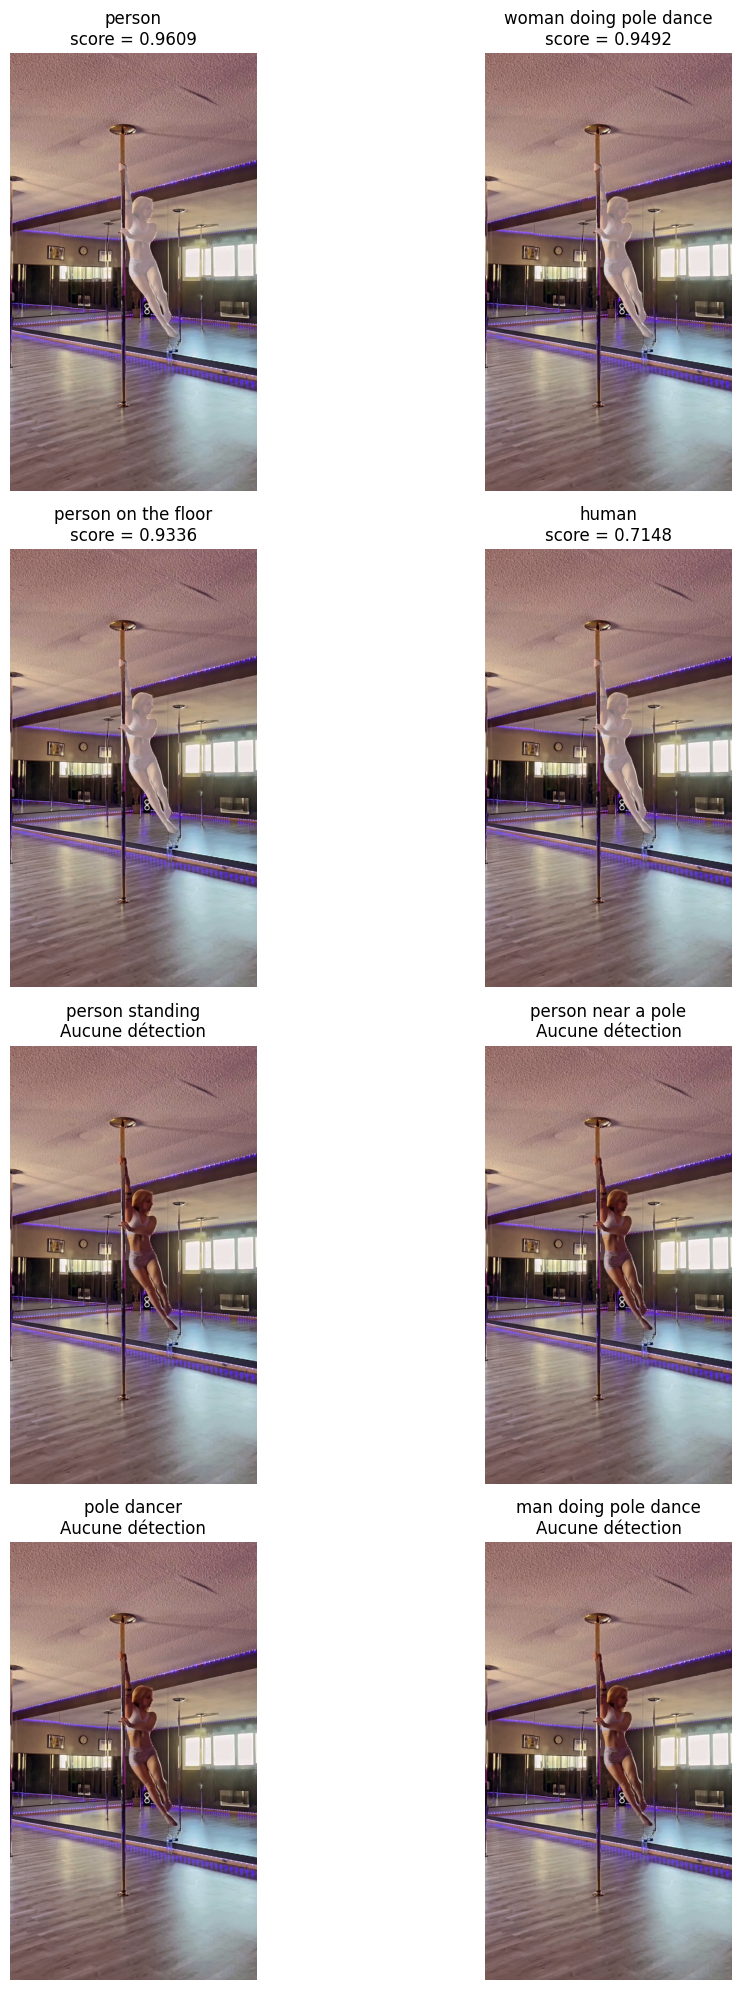

In [16]:
test_img_path = frame_paths_all[PROMPT_TEST_FRAME_INDEX]

print(f"Frame de test : {test_img_path}")

prompt_results = []

for prompt in SAM3_TEXT_PROMPTS:
    res = run_sam3_on_image(test_img_path, prompt)
    prompt_results.append(res)

    if res["has_person"]:
        print(
            f"Prompt = {prompt!r} | "
            f"score = {res['best_score']:.4f} | "
            f"box = {res['best_box']}"
        )
    else:
        print(f"Prompt = {prompt!r} | aucune détection")

# Tri décroissant par score :
prompt_results_sorted = sorted(
    prompt_results,
    key=lambda x: x["best_score"] if x["best_score"] is not None else -1.0,
    reverse=True
)

SAM3_BEST_TEXT_PROMPT = prompt_results_sorted[0]["prompt"]

print(f"\nPrompt retenu pour la vidéo : {SAM3_BEST_TEXT_PROMPT}")

visualize_sam3_prompt_results(test_img_path, prompt_results_sorted)

---

## IV. Exécution de `SAM 3` sur vidéos

### 1. Initialisation du predictor vidéo et paramètres

In [17]:
import json
import shutil
import gc

from sam3.model_builder import build_sam3_video_predictor

sam3_video_predictor = build_sam3_video_predictor()
print("Predictor SAM 3 (vidéo) chargé.")

# Paramètres :
PROMPT_FRAME_INDEX = 0
SAM3_VIDEO_TEXT_PROMPT = SAM3_BEST_TEXT_PROMPT
SAM3_PROPAGATION_DIRECTION = "forward"
SAM3_CHUNK_SIZE = 8

OUTPUT_CUTOUT_PATH = f"{RESULTS_DIRECTORY}/output_cutout.mp4"
SAM3_VIDEO_METADATA_PATH = f"{RESULTS_DIRECTORY}/sam3_video_metadata.json"

VIDEO_REFINEMENTS = []

print(f"Prompt texte vidéo : {SAM3_VIDEO_TEXT_PROMPT}")
print(f"Frame de prompt    : {PROMPT_FRAME_INDEX}")
print(f"Chunk size         : {SAM3_CHUNK_SIZE}")

INFO 2026-04-24 12:09:51,149 7491 sam3_video_predictor.py: 109: using the following GPU IDs: [0]
INFO 2026-04-24 12:09:51,152 7491 sam3_video_predictor.py: 125: 


	*** START loading model on all ranks ***


INFO 2026-04-24 12:09:51,152 7491 sam3_video_predictor.py: 127: loading model on rank=0 with world_size=1 -- this could take a while ...
INFO 2026-04-24 12:10:00,179 7491 sam3_video_base.py: 348: setting max_num_objects=10000 and num_obj_for_compile=16
INFO 2026-04-24 12:10:15,487 7491 sam3_video_predictor.py: 129: loading model on rank=0 with world_size=1 -- DONE locally
INFO 2026-04-24 12:10:15,488 7491 sam3_video_predictor.py: 140: 


	*** DONE loading model on all ranks ***




Predictor SAM 3 (vidéo) chargé.
Prompt texte vidéo : person
Frame de prompt    : 0
Chunk size         : 8


### 2. Fonctions utilitaires

In [18]:
def get_original_files(frames_dir: str = FRAMES_DIRECTORY):
    files = sorted(
        [
            f for f in os.listdir(frames_dir)
            if f.lower().endswith((".png", ".jpg", ".jpeg"))
        ]
    )

    if len(files) == 0:
        raise ValueError(f"Aucune frame image trouvée dans : {frames_dir}")

    return files

def get_proxy_files(proxy_dir: str = SAM3_PROXY_FRAMES_DIR):
    files = sorted(
        [
            f for f in os.listdir(proxy_dir)
            if f.lower().endswith(".jpg")
        ]
    )

    if len(files) == 0:
        raise ValueError(f"Aucune frame proxy JPEG trouvée dans : {proxy_dir}")

    return files

def init_video_writer_from_frames(
    files: list[str],
    frames_dir: str = FRAMES_DIRECTORY,
    output_path: str = OUTPUT_CUTOUT_PATH,
    fps: float = 30.0,
    codec: str = "mp4v",
):
    sample_frame_path = os.path.join(frames_dir, files[0])
    sample_img = cv2.imread(sample_frame_path)

    if sample_img is None:
        raise RuntimeError(f"Impossible de lire l'image : {sample_frame_path}")

    h, w = sample_img.shape[:2]
    fourcc = cv2.VideoWriter_fourcc(*codec)
    writer = cv2.VideoWriter(output_path, fourcc, fps, (w, h))

    if not writer.isOpened():
        raise RuntimeError(f"VideoWriter impossible à ouvrir : {output_path}")

    return writer, h, w

def build_local_chunk_folder(
    proxy_files: list[str],
    chunk_start: int,
    chunk_end: int,
    proxy_dir: str = SAM3_PROXY_FRAMES_DIR,
    tmp_dir: str = SAM3_TMP_CHUNK_DIR,
):
    """
    Construit un vrai chunk JPEG local pour SAM 3 :
    on évite les copies physiques quand c'est possible.
    """
    shutil.rmtree(tmp_dir, ignore_errors=True)
    os.makedirs(tmp_dir, exist_ok=True)

    local_to_global = {}

    for local_idx, global_idx in enumerate(range(chunk_start, chunk_end + 1)):
        src = os.path.join(proxy_dir, proxy_files[global_idx])
        dst = os.path.join(tmp_dir, f"{local_idx:05d}.jpg")

        try:
            os.link(src, dst)
        except Exception:
            try:
                os.symlink(src, dst)
            except Exception:
                shutil.copy2(src, dst)

        local_to_global[local_idx] = global_idx

    return tmp_dir, local_to_global

def score_from_prob(prob):
    """
    Convertit une sortie de probabilité éventuelle en score scalaire.
    """
    arr = np.asarray(to_numpy(prob), dtype=np.float32).reshape(-1)
    if arr.size == 0:
        return 0.0
    return float(arr.max())

def masks_to_list(masks_raw):
    """
    Convertit out_binary_masks en liste de masques individuels.
    """
    if torch.is_tensor(masks_raw):
        if masks_raw.ndim == 2:
            return [masks_raw]
        return [masks_raw[i] for i in range(masks_raw.shape[0])]

    masks_np = np.asarray(masks_raw)
    if masks_np.ndim == 2:
        return [masks_np]
    return [masks_np[i] for i in range(masks_np.shape[0])]

def parse_outputs_to_items(outputs):
    """
    Convertit le format de sortie observé :
      {
        'out_obj_ids': ...,
        'out_probs': ...,
        'out_boxes_xywh': ...,
        'out_binary_masks': ...,
        'frame_stats': ...
      }

    en une liste normalisée d'objets :
      [
        {
          'obj_id': ...,
          'score': ...,
          'bbox_xywh': ...,
          'mask': ...
        },
        ...
      ]
    """
    if not isinstance(outputs, dict):
        raise TypeError(f"outputs doit être un dict, reçu : {type(outputs)}")

    required_keys = ["out_obj_ids", "out_probs", "out_boxes_xywh", "out_binary_masks"]
    missing = [k for k in required_keys if k not in outputs]
    if missing:
        raise KeyError(f"Clés manquantes dans outputs : {missing}")

    obj_ids = np.asarray(to_numpy(outputs["out_obj_ids"])).reshape(-1)
    probs_raw = outputs["out_probs"]
    boxes = np.asarray(to_numpy(outputs["out_boxes_xywh"]))
    masks_list = masks_to_list(outputs["out_binary_masks"])

    if boxes.ndim == 1:
        boxes = boxes[None, :]

    probs_arr = np.asarray(to_numpy(probs_raw), dtype=np.float32)
    if probs_arr.ndim == 0:
        probs_arr = probs_arr[None]

    if probs_arr.ndim > 1:
        probs_arr = probs_arr.reshape(probs_arr.shape[0], -1)

    n = min(len(obj_ids), len(boxes), len(masks_list), len(probs_arr))

    items = []
    for i in range(n):
        prob_i = probs_arr[i]
        score_i = score_from_prob(prob_i)

        items.append(
            {
                "obj_id": int(obj_ids[i]),
                "score": score_i,
                "bbox_xywh": np.asarray(boxes[i], dtype=np.float32).tolist(),
                "mask": normalize_binary_mask(masks_list[i]),
            }
        )

    return items

def select_best_item(items):
    """
    Sélectionne l'objet le plus probable, puis le plus grand en aire.
    """
    if len(items) == 0:
        return None

    return max(
        items,
        key=lambda x: (float(x["score"]), int(x["mask"].sum()))
    )

def find_item_by_obj_id(items, obj_id):
    for item in items:
        if int(item["obj_id"]) == int(obj_id):
            return item
    return None

def scale_points_abs(points_abs, src_w: int, src_h: int, dst_w: int, dst_h: int):
    """
    Recale des points (pixels) du repère original vers le repère proxy.
    """
    pts = np.asarray(points_abs, dtype=np.float32).copy()
    pts[:, 0] *= float(dst_w) / float(src_w)
    pts[:, 1] *= float(dst_h) / float(src_h)
    return pts.tolist()

def write_single_frame_with_mask(
    frame_idx: int,
    files: list[str],
    writer,
    mask,
    frames_dir: str = FRAMES_DIRECTORY,
    masks_dir: str = MASKS_DIRECTORY,
):
    frame_name = files[frame_idx]
    img_path = os.path.join(frames_dir, frame_name)

    img = cv2.imread(img_path)
    if img is None:
        raise RuntimeError(f"Impossible de lire l'image : {img_path}")

    H, W = img.shape[:2]

    if mask is None:
        mask_bool = np.zeros((H, W), dtype=bool)
    else:
        mask_bool = normalize_binary_mask(mask)

        if mask_bool.shape != (H, W):
            mask_bool = cv2.resize(
                mask_bool.astype(np.uint8),
                (W, H),
                interpolation=cv2.INTER_NEAREST,
            ) > 0

    cv2.imwrite(
        os.path.join(masks_dir, f"{frame_idx:05d}.png"),
        (mask_bool * 255).astype(np.uint8),
    )

    cutout = np.zeros_like(img)
    cutout[mask_bool] = img[mask_bool]
    writer.write(cutout)

def run_sam3_video_pipeline_chunked(
    frames_dir: str = FRAMES_DIRECTORY,
    proxy_dir: str = SAM3_PROXY_FRAMES_DIR,
    masks_dir: str = MASKS_DIRECTORY,
    output_path: str = OUTPUT_CUTOUT_PATH,
    prompt_frame_index: int = PROMPT_FRAME_INDEX,
    text_prompt: str = SAM3_VIDEO_TEXT_PROMPT,
    refinements: list[dict] = VIDEO_REFINEMENTS,
    chunk_size: int = SAM3_CHUNK_SIZE,
):
    """
    Pipeline SAM 3 vidéo (sous forme de chunks).
    Écriture des sorties au fil de l'eau, sans accumuler tout le chunk en mémoire.
    """
    files = get_original_files(frames_dir)
    proxy_files = get_proxy_files(proxy_dir)

    if len(files) != len(proxy_files):
        raise RuntimeError(
            f"Le nombre de frames originales ({len(files)}) "
            f"et proxy ({len(proxy_files)}) ne correspond pas."
        )

    if not (0 <= prompt_frame_index < len(files)):
        raise ValueError(
            f"PROMPT_FRAME_INDEX invalide : {prompt_frame_index} "
            f"(nombre de frames = {len(files)})."
        )

    shutil.rmtree(masks_dir, ignore_errors=True)
    os.makedirs(masks_dir, exist_ok=True)

    writer, orig_H, orig_W = init_video_writer_from_frames(
        files=files,
        frames_dir=frames_dir,
        output_path=output_path,
    )

    proxy_sample = cv2.imread(os.path.join(proxy_dir, proxy_files[0]))
    if proxy_sample is None:
        raise RuntimeError("Impossible de lire la première frame proxy.")
    proxy_H, proxy_W = proxy_sample.shape[:2]

    current_start = int(prompt_frame_index)

    try:
        while current_start < len(files):
            current_end = min(len(files) - 1, current_start + chunk_size - 1)

            print(f"\n=== Chunk réel {current_start} -> {current_end} ===")

            chunk_dir, local_to_global = build_local_chunk_folder(
                proxy_files=proxy_files,
                chunk_start=current_start,
                chunk_end=current_end,
                proxy_dir=proxy_dir,
                tmp_dir=SAM3_TMP_CHUNK_DIR,
            )

            session_id = sam3_video_predictor.handle_request(
                request=dict(
                    type="start_session",
                    resource_path=chunk_dir,
                )
            )["session_id"]

            try:
                # Prompt texte au début du chunk :
                response = sam3_video_predictor.handle_request(
                    request=dict(
                        type="add_prompt",
                        session_id=session_id,
                        frame_index=0,
                        text=text_prompt,
                    )
                )

                outputs0 = response["outputs"]
                items0 = parse_outputs_to_items(outputs0)

                if len(items0) == 0:
                    raise RuntimeError(
                        f"Aucun objet renvoyé au début du chunk {current_start}."
                    )

                selected0 = select_best_item(items0)
                obj_id = selected0["obj_id"]

                print(
                    f"Objet suivi : {obj_id} | "
                    f"score = {selected0['score']:.4f}"
                )

                # Raffinements optionnels :
                for ref in refinements:
                    gidx = int(ref["frame_index"])
                    if not (current_start <= gidx <= current_end):
                        continue

                    local_idx = gidx - current_start
                    scaled_points = scale_points_abs(
                        ref["points_abs"],
                        src_w=orig_W,
                        src_h=orig_H,
                        dst_w=proxy_W,
                        dst_h=proxy_H,
                    )

                    _ = sam3_video_predictor.handle_request(
                        request=dict(
                            type="add_prompt",
                            session_id=session_id,
                            frame_index=local_idx,
                            points=scaled_points,
                            point_labels=ref["point_labels"],
                            obj_id=obj_id,
                        )
                    )

                # Écriture immédiate de la première frame du chunk :
                write_single_frame_with_mask(
                    frame_idx=current_start,
                    files=files,
                    writer=writer,
                    mask=selected0["mask"],
                    frames_dir=frames_dir,
                    masks_dir=masks_dir,
                )

                written_frames = {current_start}

                for response in sam3_video_predictor.handle_stream_request(
                    request=dict(
                        type="propagate_in_video",
                        session_id=session_id,
                        propagation_direction=SAM3_PROPAGATION_DIRECTION,
                        start_frame_index=0,
                        max_frame_num_to_track=(current_end - current_start + 1),
                    )
                ):
                    local_idx = int(response["frame_index"])

                    if local_idx not in local_to_global:
                        continue

                    items = parse_outputs_to_items(response["outputs"])
                    matched = find_item_by_obj_id(items, obj_id)

                    # Fallback : si un seul objet subsiste, on le garde.
                    if matched is None and len(items) == 1:
                        matched = items[0]

                    global_idx = local_to_global[local_idx]

                    if global_idx in written_frames:
                        continue

                    mask = None if matched is None else matched["mask"]

                    write_single_frame_with_mask(
                        frame_idx=global_idx,
                        files=files,
                        writer=writer,
                        mask=mask,
                        frames_dir=frames_dir,
                        masks_dir=masks_dir,
                    )

                    written_frames.add(global_idx)

                # Si certaines frames du chunk n'ont pas été renvoyées,
                # on écrit un masque vide pour garder la continuité :
                for frame_idx in range(current_start, current_end + 1):
                    if frame_idx in written_frames:
                        continue

                    write_single_frame_with_mask(
                        frame_idx=frame_idx,
                        files=files,
                        writer=writer,
                        mask=None,
                        frames_dir=frames_dir,
                        masks_dir=masks_dir,
                    )

                print(f"Chunk écrit : {current_start} -> {current_end}")
                current_start = current_end + 1

            finally:
                _ = sam3_video_predictor.handle_request(
                    request=dict(
                        type="close_session",
                        session_id=session_id,
                    )
                )

                shutil.rmtree(chunk_dir, ignore_errors=True)
                gc.collect()
                torch.cuda.empty_cache()

        print(f"\nVidéo finale générée sous : {output_path}")

    finally:
        writer.release()

    metadata = {
        "prompt_frame_index": int(prompt_frame_index),
        "text_prompt": text_prompt,
        "chunk_size": int(chunk_size),
        "num_frames": len(files),
        "proxy_height": int(proxy_H),
        "refinements": refinements,
    }

    with open(SAM3_VIDEO_METADATA_PATH, "w", encoding="utf-8") as f:
        json.dump(metadata, f, indent=4)

    print(f"Métadonnées sauvegardées dans : {SAM3_VIDEO_METADATA_PATH}")

    return {
        "files": files,
        "metadata": metadata,
    }

### 3. Exécution de `SAM 3`

In [19]:
print(f"Prompt utilisé : {SAM3_VIDEO_TEXT_PROMPT}")
print(f"Frame de prompt : {PROMPT_FRAME_INDEX}")
print(f"Nombre de raffinements : {len(VIDEO_REFINEMENTS)}")
print(f"Chunk size : {SAM3_CHUNK_SIZE}")
print(f"Proxy height : {SAM3_PROXY_MAX_HEIGHT}")

SAM3_RUN = run_sam3_video_pipeline_chunked(
    frames_dir=FRAMES_DIRECTORY,
    proxy_dir=SAM3_PROXY_FRAMES_DIR,
    masks_dir=MASKS_DIRECTORY,
    output_path=OUTPUT_CUTOUT_PATH,
    prompt_frame_index=PROMPT_FRAME_INDEX,
    text_prompt=SAM3_VIDEO_TEXT_PROMPT,
    refinements=VIDEO_REFINEMENTS,
    chunk_size=SAM3_CHUNK_SIZE,
)

Prompt utilisé : person
Frame de prompt : 0
Nombre de raffinements : 0
Chunk size : 8
Proxy height : 720

=== Chunk réel 0 -> 7 ===


frame loading (image folder) [rank=0]: 100%|██████████| 8/8 [00:00<00:00, 35.79it/s]
INFO 2026-04-24 12:10:15,950 7491 sam3_base_predictor.py: 133: started new session d874313b-8f69-415c-a8cb-d57267367c1f


Objet suivi : 0 | score = 0.9649


propagate_in_video:   0%|          | 0/8 [00:00<?, ?it/s]

INFO 2026-04-24 12:10:52,004 7491 sam3_base_predictor.py: 289: propagation ended in session d874313b-8f69-415c-a8cb-d57267367c1f
INFO 2026-04-24 12:10:52,273 7491 sam3_base_predictor.py: 308: removed session d874313b-8f69-415c-a8cb-d57267367c1f


...

propagate_in_video:   0%|          | 0/1 [00:00<?, ?it/s]

INFO 2026-04-24 13:36:13,108 7491 sam3_base_predictor.py: 289: propagation ended in session 9c1b5d26-a47e-408e-8505-582bbe723073


Chunk écrit : 1328 -> 1328


INFO 2026-04-24 13:36:13,443 7491 sam3_base_predictor.py: 308: removed session 9c1b5d26-a47e-408e-8505-582bbe723073



Vidéo finale générée sous : /content/working_dir/results/output_cutout.mp4
Métadonnées sauvegardées dans : /content/working_dir/results/sam3_video_metadata.json


### 4. Visualisation qualitative des masques

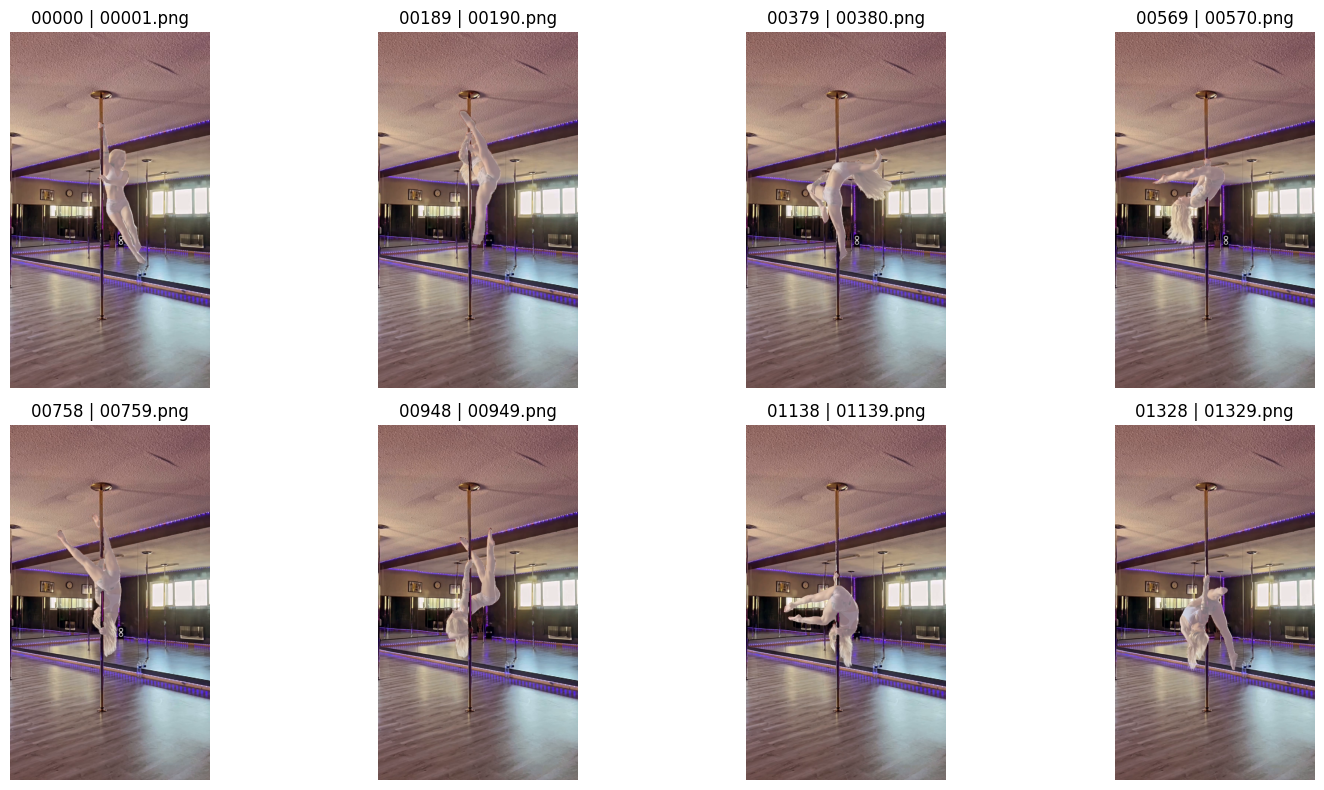

In [20]:
def visualize_sam3_video_masks(
    files: list[str],
    frames_dir: str = FRAMES_DIRECTORY,
    masks_dir: str = MASKS_DIRECTORY,
    num_examples: int = 8,
):
    """
    Affiche quelques overlays image + masque pour vérifier qualitativement la segmentation.
    """
    if len(files) == 0:
        print("Aucune frame à visualiser.")
        return

    num_examples = min(num_examples, len(files))
    indices = np.linspace(0, len(files) - 1, num_examples, dtype=int)

    cols = 4
    rows = int(np.ceil(num_examples / cols))

    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, idx in enumerate(indices, start=1):
        frame_name = files[idx]
        frame_path = os.path.join(frames_dir, frame_name)
        mask_path = os.path.join(masks_dir, f"{idx:05d}.png")

        img_bgr = cv2.imread(frame_path)
        mask_gray = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        if img_bgr is None:
            continue

        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

        if mask_gray is None:
            overlay = img_rgb
        else:
            mask_bool = mask_gray > 127
            overlay = overlay_mask_on_rgb(img_rgb, mask_bool)

        ax = plt.subplot(rows, cols, i)
        ax.imshow(overlay)
        ax.set_title(f"{idx:05d} | {frame_name}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

visualize_sam3_video_masks(SAM3_RUN["files"])

---

## V. Réinsertion dans un nouvel environnement

On a, pour chaque frame de la vidéo, une image + un masque (SAM 2) qui découpe la danseuse.  
Le nouveau fond n’a pas la même taille et la barre de pole n’est pas au même endroit : si on “colle” directement la danseuse, elle est mal alignée.

L’idée est donc d’utiliser la **barre** comme repère commun :
- On choisit **2 points** sur la barre dans la vidéo (haut / bas).
- On choisit les **2 mêmes points** sur la barre dans le nouveau fond.
- À partir de ces deux segments, on calcule une transformation **rotation + scale + translation** (similarity transform) qui envoie la barre de la vidéo sur la barre du fond.
- Pour chaque frame, on applique cette même transformation au **calque danseuse** (image) et à son **masque alpha**, puis on fait le **compositing** sur le nouveau fond :
  - `out = img_warp * alpha + bg * (1 - alpha)`.

Point important : les masques étant sauvegardés avec un index “liste” (`00000.png`, `00001.png`, ...), on associe correctement **frame i <=> masque i** (et pas via le numéro dans le nom `frame_0001.png`).

In [21]:
NEW_BG_PATH = f"{WORKING_DIR}/new_background.png"
OUTPUT_NEW_BACKGROUNG_PATH = f"{RESULTS_DIRECTORY}/output_with_new_background.mp4"

# Coordonnées de la barre sur la vidéo d'entrée (la barre est fixe) :
  # dataset_1 :
SRC_POLE_TOP = (492, 363)
SRC_POLE_BOTTOM = (496, 1544)
  # dataset_2 :
SRC_POLE_TOP = (669, 79)
SRC_POLE_BOTTOM = (656, 640)

# Coordonnées de la barre sur l'image de sortie :
DST_POLE_TOP = (470, 185)
DST_POLE_BOTTOM = (470, 828)

In [22]:
import re

def similarity_affine_from_2pts(src_top: tuple, src_bottom: tuple, dst_top: tuple, dst_bottom: tuple):
    """
    Construit une matrice affine 2x3 (rotation+scale+translation) telle que :
      src_top --> (aille sur) dst_top
      src_bottom --> (aille sur) dst_bottom
    Les points sont en (x, y) pixels.
    """
    src_top = np.array(src_top, dtype=np.float32)
    src_bottom = np.array(src_bottom, dtype=np.float32)
    dst_top = np.array(dst_top, dtype=np.float32)
    dst_bottom = np.array(dst_bottom, dtype=np.float32)

    v_src = src_bottom - src_top
    v_dst = dst_bottom - dst_top

    norm_src = float(np.linalg.norm(v_src))
    norm_dst = float(np.linalg.norm(v_dst))
    if norm_src < 1e-6:
        raise ValueError("src_top et src_bottom sont trop proches (norme ~ 0).")

    # Scale :
    s = norm_dst / norm_src

    # Rotation :
    ang_src = np.arctan2(v_src[1], v_src[0])
    ang_dst = np.arctan2(v_dst[1], v_dst[0])
    theta = float(ang_dst - ang_src)

    c = np.cos(theta)
    sn = np.sin(theta)

    # M = s*R
    M2 = s * np.array([[c, -sn],
                       [sn,  c]], dtype=np.float32)

    # translation : dst_top = M2 @ src_top + t
    t = dst_top - (M2 @ src_top)

    # Matrice 2x3 pour cv2.warpAffine :
    A = np.array([[M2[0,0], M2[0,1], t[0]],
                  [M2[1,0], M2[1,1], t[1]]], dtype=np.float32)
    return A

def render_with_background_aligned_on_pole(
    files,
    src_pole_top = SRC_POLE_TOP,
    src_pole_bottom = SRC_POLE_BOTTOM,
    dst_pole_top = DST_POLE_TOP,
    dst_pole_bottom = DST_POLE_BOTTOM,
    bg_path = NEW_BG_PATH,
    frames_dir = FRAMES_DIRECTORY,
    mask_dir = MASKS_DIRECTORY,
    output_path = OUTPUT_NEW_BACKGROUNG_PATH,
    fps = 30.0,
    codec = "mp4v",
    feather_sigma = 2.0
):
    bg = cv2.imread(bg_path, cv2.IMREAD_COLOR)
    if bg is None:
        raise FileNotFoundError(f"Fond introuvable: {bg_path}")
    out_h, out_w = bg.shape[:2]

    A = similarity_affine_from_2pts(src_pole_top, src_pole_bottom, dst_pole_top, dst_pole_bottom)

    mask_offset = 0 if os.path.exists(os.path.join(mask_dir, "00000.png")) else 1

    fourcc = cv2.VideoWriter_fourcc(*codec)
    writer = cv2.VideoWriter(output_path, fourcc, fps, (out_w, out_h))
    if not writer.isOpened():
        raise RuntimeError(f"VideoWriter impossible à ouvrir: {output_path}")

    for i, f in enumerate(files):
        frame_path = os.path.join(frames_dir, f)
        img = cv2.imread(frame_path, cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(f"Frame introuvable: {frame_path}")

        mask_path = os.path.join(mask_dir, f"{i + mask_offset:05d}.png")
        m = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if m is None:
            raise FileNotFoundError(f"Masque introuvable: {mask_path}")

        alpha = (m.astype(np.float32) / 255.0)

        img_warp = cv2.warpAffine(
            img, A, (out_w, out_h),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=(0, 0, 0)
        )
        alpha_warp = cv2.warpAffine(
            alpha, A, (out_w, out_h),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=0
        )

        if feather_sigma and feather_sigma > 0:
            alpha_warp = cv2.GaussianBlur(alpha_warp, (0, 0), feather_sigma)
        alpha_warp = np.clip(alpha_warp, 0.0, 1.0)

        out = img_warp.astype(np.float32) * alpha_warp[..., None] + bg.astype(np.float32) * (1.0 - alpha_warp[..., None])
        out_u8 = out.astype(np.uint8)

        writer.write(out_u8)

    writer.release()
    print(f"Vidéo finale générée sous \"{output_path}\".")

In [23]:
render_with_background_aligned_on_pole(SAM3_RUN["files"])

Vidéo finale générée sous "/content/working_dir/results/output_with_new_background.mp4".


---

## VI. Analyse de métriques pour évaluer la reconstruction vidéo

### 1. Métrique : aires

Fonctions utilitaires puis d'affichage :

In [24]:
import cv2
import numpy as np
import glob

def get_mask_area(mask_path):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return 0
    return int(np.sum(mask > 127))

def get_masks_areas(masks_dir):
    mask_files = sorted(glob.glob(os.path.join(masks_dir, "*.png")))
    areas = []
    for filepath in mask_files:
        area = get_mask_area(filepath)
        areas.append(area)
    return areas

def get_second_derivative_areas(areas):
    if len(areas) < 5:
        print("Série trop courte pour calculer une dérivée seconde.")
        return []
    second_deriv = np.gradient(np.gradient(areas))

    # Neutralisation des effets de bord
    second_deriv[0] = 0
    second_deriv[1] = 0
    second_deriv[2] = 0
    second_deriv[-1] = 0
    second_deriv[-2] = 0
    second_deriv[-3] = 0

    return second_deriv.tolist()

def get_peak_indices(second_deriv, threshold):
    peaks = []
    for i, val in enumerate(second_deriv):
        if abs(val) > threshold:
            peaks.append((i, val))
    return peaks

def get_areas_adaptive_threshold(areas, sensitivity_percent = 10):
    if not areas:
        print("La liste des aires est vide.")
        return 0
    avg_area = np.mean(areas)
    threshold = avg_area * (sensitivity_percent / 100)

    return threshold

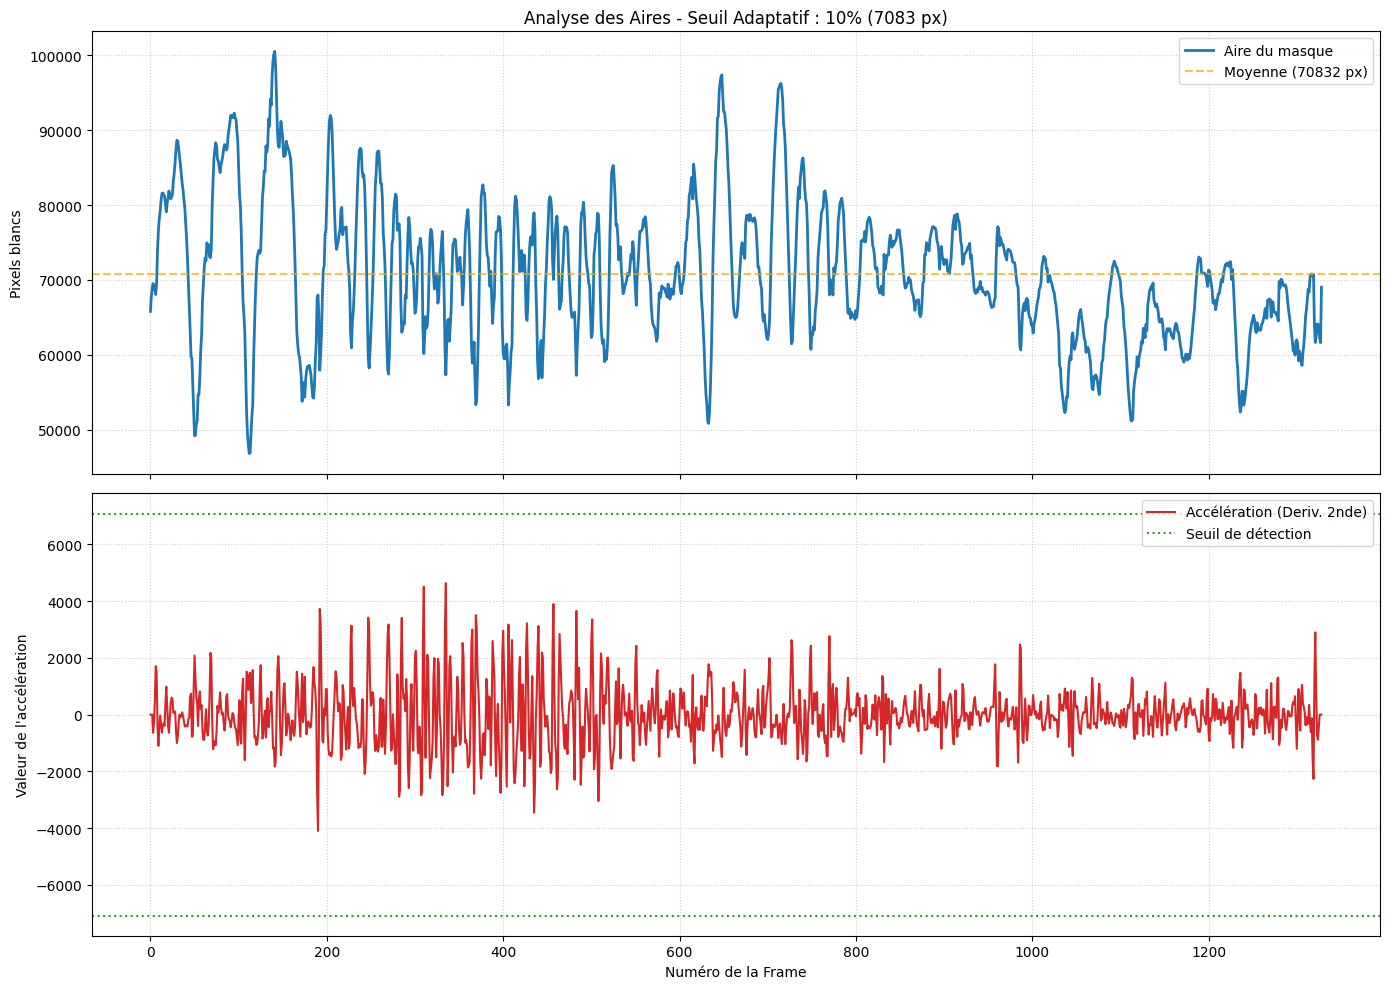

In [25]:
import matplotlib.pyplot as plt

def plot_area_analysis(masks_dir, sensitivity_percent=10):
    # Récupération des données
    areas = get_masks_areas(masks_dir)
    if not areas:
        print("Erreur : Aucune donnée d'aire récupérée.")
        return []
    threshold = get_areas_adaptive_threshold(areas, sensitivity_percent)
    second_deriv = get_second_derivative_areas(areas)

    peaks = get_peak_indices(second_deriv, threshold)
    peak_indices = [p[0] for p in peaks]
    peak_values = [p[1] for p in peaks]

    # Graphiques
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    frames = range(len(areas))
    avg_area = np.mean(areas)

    # Graphique 1 : Aires
    ax1.plot(frames, areas, color='#1f77b4', linewidth=2, label="Aire du masque")
    ax1.axhline(y=avg_area, color='orange', linestyle='--', alpha=0.7, label=f"Moyenne ({int(avg_area)} px)")
    ax1.set_ylabel("Pixels blancs")
    ax1.set_title(f"Analyse des Aires - Seuil Adaptatif : {sensitivity_percent}% ({int(threshold)} px)")
    ax1.legend(loc='upper right')
    ax1.grid(True, linestyle=':', alpha=0.6)

    # Graphique 2 : Accélaration de l'aire
    ax2.plot(frames, second_deriv, color='#d62728', linewidth=1.5, label="Accélération (Deriv. 2nde)")
    ax2.axhline(y=threshold, color='green', linestyle=':', alpha=0.8, label="Seuil de détection")
    ax2.axhline(y=-threshold, color='green', linestyle=':', alpha=0.8)
    ax2.set_xlabel("Numéro de la Frame")
    ax2.set_ylabel("Valeur de l'accélération")
    ax2.legend(loc='upper right')
    ax2.grid(True, linestyle=':', alpha=0.6)

    if peak_indices: # Annotations des numéros de frames des pics
        ax2.scatter(peak_indices, peak_values, color='black', s=30, zorder=5, label="Pics (Anomalies)")
        for idx, val in peaks:
            ax2.annotate(f"F{idx}", (idx, val), textcoords="offset points", xytext=(0,10),ha='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

    return peaks

pics_anomalies = plot_area_analysis(MASKS_DIRECTORY, sensitivity_percent=10)

### 2. Métrique : histogrammes des images et distance de Bhattacharyya

#### A. Fonctions utilitaires

In [26]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

def get_bhattacharyya_distance_paths(mask1_path, mask2_path):
    m1_img = cv2.imread(mask1_path, cv2.IMREAD_GRAYSCALE)
    m2_img = cv2.imread(mask2_path, cv2.IMREAD_GRAYSCALE)
    if m1_img is None or m2_img is None: return 1.0

    # Conversion en matrices de floats 0.0 / 1.0 avant le calcul
    m1 = (m1_img > 127).astype(np.float32)
    m2 = (m2_img > 127).astype(np.float32)

    return get_bhattacharyya_distance(m1, m2)

def get_bhattacharyya_distance(m1, m2):
    """ Compare deux matrices de floats (0.0 à 1.0) via projections X et Y. """
    if m1 is None or m2 is None: return 1.0

    # Étape 1 : Calcul des projections (Profils d'intensité)
    h1x = np.sum(m1, axis=0).astype(np.float32)
    h1y = np.sum(m1, axis=1).astype(np.float32)
    h2x = np.sum(m2, axis=0).astype(np.float32)
    h2y = np.sum(m2, axis=1).astype(np.float32)

    # Étape 2 : Normalisation en distributions de probabilité
    for h in [h1x, h1y, h2x, h2y]:
        s = np.sum(h)
        if s > 0: h /= s

    # Étape 3 : Comparaison statistique
    dx = cv2.compareHist(h1x, h2x, cv2.HISTCMP_BHATTACHARYYA)
    dy = cv2.compareHist(h1y, h2y, cv2.HISTCMP_BHATTACHARYYA)

    return (dx + dy) / 2

def get_mask_overlay_in_folder(folder_path, mask_idx, window_size=2):
    """ Renvoie un combinaison des masques adjacents selon la taille du paramètre window_size.
        N'inclut pas la frame dont l'index est donné en paramètre.
        Les frames adjacentes qui n'existent pas (par exemple aux bords) son ignorées.
        Un masque vide est renvoyé si il n'existe pas de voisins valides. """
    mask_shape = cv2.imread(os.path.join(folder_path, f"{mask_idx:05d}.png"), cv2.IMREAD_GRAYSCALE).shape
    overlay = np.zeros(mask_shape, dtype=np.float32)
    if window_size <= 0: return overlay

    # Étape 1 : Récupération des paths des masques valides
    neighbor_paths = []
    valid_count = 0
    for i in range(mask_idx - window_size, mask_idx + window_size + 1):
        mask_path = os.path.join(folder_path, f"{i:05d}.png")
        if i != mask_idx and os.path.exists(mask_path):
            neighbor_paths.append(mask_path)

    # Étape 2 : Combinaison en une distribution unique et coefficientée
    for path in neighbor_paths:
        image = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if image is not None:
            mask = (image > 127).astype(np.float32)
            overlay += mask

    return overlay / len(neighbor_paths) if len(neighbor_paths) > 0 else overlay

#### B. Fonctions d'affichage

In [27]:
def plot_battacharyya_analysis(distances, threshold=0.25):
    """ Génère les graphiques : distribution et courbe temporelle empilés verticalement. """
    if not distances:
        print("Aucune distance à traiter.")
        return []

    mean_distance = np.mean(distances)
    stability_score = (1 - mean_distance) * 100

    print(f"Nombre de transitions : {len(distances)}")
    print(f"Distance moyenne entre les frames : {mean_distance:.6f}")
    print(f"Score de stabilité : {stability_score:.2f}%")

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10))

    # 1. Histogramme (Distribution des distances)
    ax1.hist(distances, bins=50, color='#3498db', edgecolor='black', alpha=0.7)
    ax1.set_title("Distribution de l'instabilité")
    ax1.set_xlabel("Distance (0=Stable, 1=Incohérent)")
    ax1.set_ylabel("Nombre de transitions")

    # 2. Courbe temporelle (le graphique amélioré)
    ax2.plot(distances, color='#3498db', linewidth=0.8, label="Distance de Bhattacharyya")
    ax2.axhline(y=threshold, color='#e74c3c', linestyle='--', label=f'Seuil ({threshold})')

    # Remplissage des zones d'erreur au-dessus du seuil
    ax2.fill_between(range(len(distances)), distances, threshold,
                     where=(np.array(distances) > threshold),
                     color='#e74c3c', alpha=0.3, label="Incohérence détectée")
    ax2.set_title("Évolution de la stabilité temporelle", fontsize=12)
    ax2.set_xlabel("Temps (Index de la frame t -> t+1)")
    ax2.set_ylabel("Amplitude de la modification")
    ax2.set_ylim(0, max(distances) + 0.05 if distances else 1)
    ax2.legend(loc='upper right')
    ax2.grid(axis='y', alpha=0.3)
    plt.tight_layout() # Évite que les titres ne chevauchent les axes
    plt.show()

    return [idx for idx, val in enumerate(distances) if val > threshold]

def battacharrya_analysis_in_folder(input_path, threshold=0.25, window_size=0):
    """ Analyse les masques dans un dossier contenant uniquement ces masques avec
        la distance de Battacharyya.
        - Si window_size=0, calcule la distance sur la prochaine frame uniquement
        - Si window_size>0, soit une frame d'index i, réalise un overlay (fusion)
        sur les masques adjacents correspondant à [i-window_size; i+window_size]\{i},
        puis compare la frame i à toutes celles de l'overlay"""
    files = sorted([f for f in os.listdir(input_path) if f.lower().endswith('.png')])
    distances = []

    iterations = range(len(files) - 1) if window_size == 0 else range(len(files))
    for i in tqdm(iterations):
        if window_size == 0: # Mode sans overlay : comparaison frame i/i+1
            path1 = os.path.join(input_path, files[i])
            path2 = os.path.join(input_path, files[i+1])
            distances.append(get_bhattacharyya_distance_paths(path1, path2))
        else: # Mode avec overlay : t contre moyenne du voisinage
            img = cv2.imread(os.path.join(input_path, files[i]), cv2.IMREAD_GRAYSCALE)
            mask = (img > 127).astype(np.float32) if img is not None else None
            overlay = get_mask_overlay_in_folder(input_path, i, window_size)
            distances.append(get_bhattacharyya_distance(mask, overlay))

    bad_indexes = plot_battacharyya_analysis(distances, threshold)
    return distances, bad_indexes

def display_frames_in_window(folder_path, frame_index, window_size=2):
    files = os.listdir(folder_path)
    if not files: return None
    reference_image = cv2.imread(os.path.join(folder_path,  files[0]))
    height, width, _ = reference_image.shape

    film = []
    for i in range(frame_index - window_size, frame_index + window_size + 1):
        frame_path = os.path.join(folder_path, f"{i:05d}.png")

        if os.path.exists(frame_path):
            current_frame = cv2.imread(frame_path)
            current_frame = cv2.cvtColor(current_frame, cv2.COLOR_BGR2RGB)
        else:
            current_frame = np.zeros((height, width, 3), dtype=np.uint8)

        separator = np.zeros((height, 5, 3), dtype=np.uint8)
        separator[:, :, 0] = 255 # Coloration en rouge

        film.append(current_frame)
        film.append(separator)

    plt.figure(figsize=(20, 6))
    plt.imshow(np.hstack(film[:-1])) # On montre les images côtes à côtes
    plt.title(f"Séquence de frames centrée sur la frame n°{frame_index}", fontsize=14)
    plt.axis('off')
    plt.show()

def visualize_top_anomalies(folder_path, distances_result, bad_frames, number_frames=5, window_size=2):
    bad_frames_with_scores = [(idx, distances_result[idx]) for idx in bad_frames]
    bad_frames_sorted = sorted(bad_frames_with_scores, key=lambda x: x[1], reverse=True)

    print(f"Nombre d'anomalies détectées : {len(bad_frames_sorted)}")
    for i in range(min(number_frames, len(bad_frames_sorted))):
        frame_idx, score = bad_frames_sorted[i]
        print(f"\nAnomalie n°{i+1}")
        print(f"Frame Index: {frame_idx} | Score d'incohérence: {score:.4f}")

        display_frames_in_window(folder_path, frame_idx, window_size)

<>:46: SyntaxWarning: invalid escape sequence '\{'
<>:46: SyntaxWarning: invalid escape sequence '\{'
/tmp/ipykernel_7491/3478227964.py:46: SyntaxWarning: invalid escape sequence '\{'
  sur les masques adjacents correspondant à [i-window_size; i+window_size]\{i},


#### C. Execution de la métrique seule

<u>Execution 1 :</u>

Battachryya simple (on analyse avec la frame suivante).

  0%|          | 0/1328 [00:00<?, ?it/s]

Nombre de transitions : 1328
Distance moyenne entre les frames : 0.068596
Score de stabilité : 93.14%


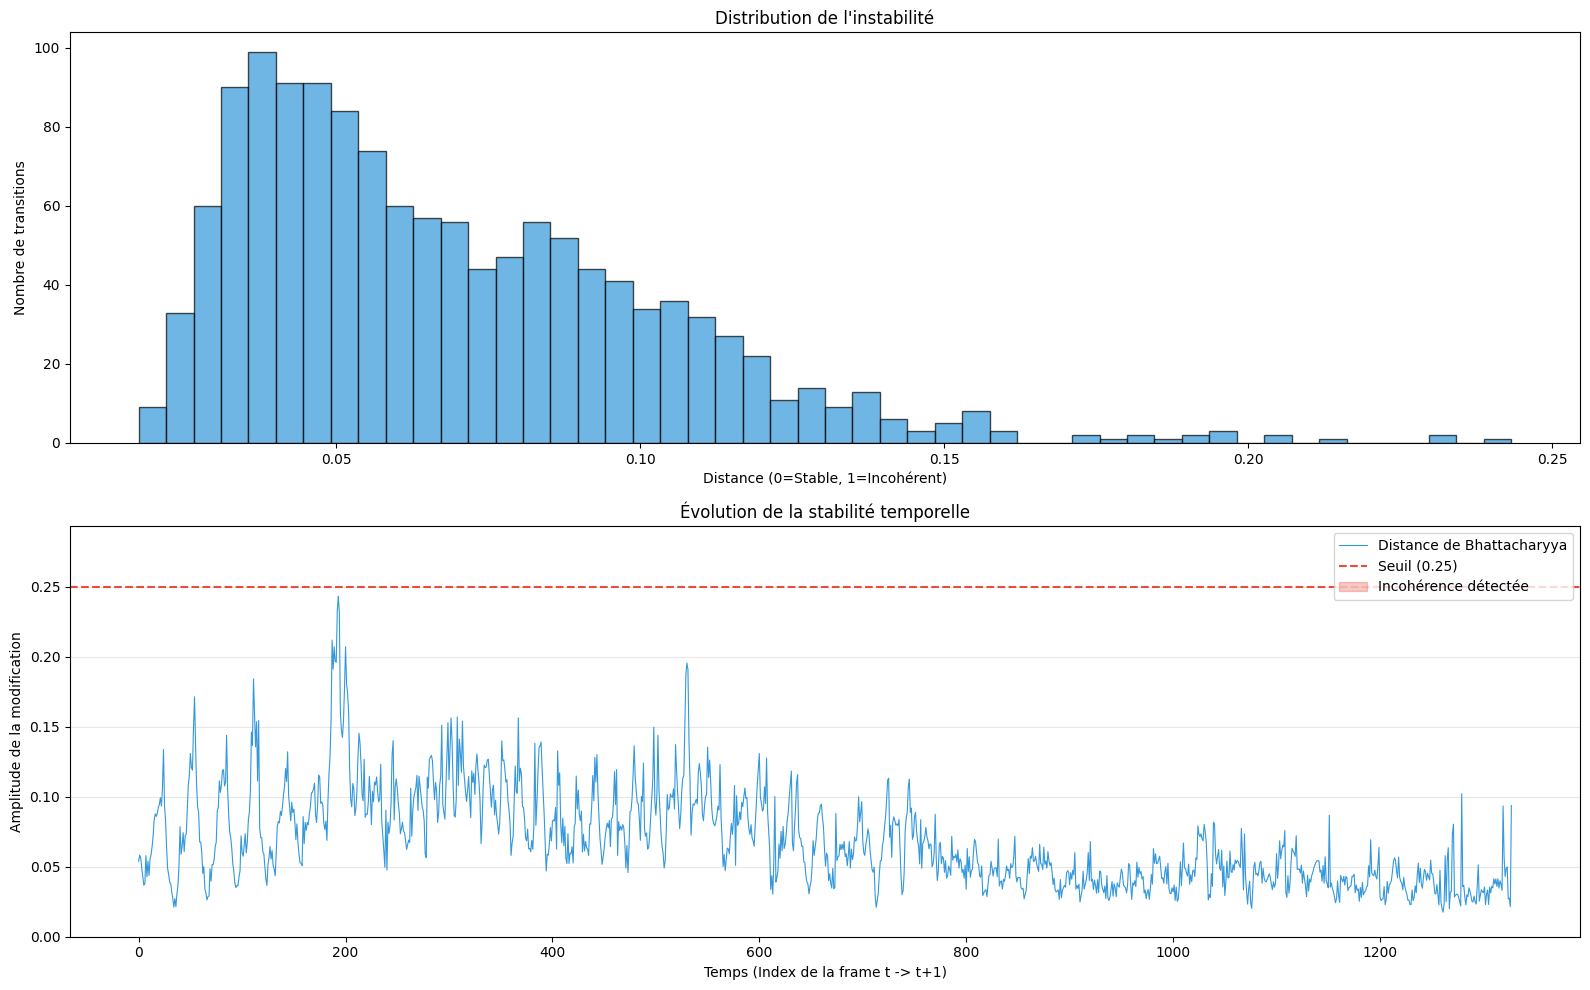

In [28]:
threshold = 0.25
distances_simple, bad_frames_simple = battacharrya_analysis_in_folder(MASKS_DIRECTORY, threshold);

In [29]:
frames_to_visualize = 10
visualize_top_anomalies(MASKS_DIRECTORY, distances_simple, bad_frames_simple, frames_to_visualize, 1)

Nombre d'anomalies détectées : 0


<u>Execution 2 :</u>

Avec overlay.

  0%|          | 0/1329 [00:00<?, ?it/s]

Nombre de transitions : 1329
Distance moyenne entre les frames : 0.059408
Score de stabilité : 94.06%


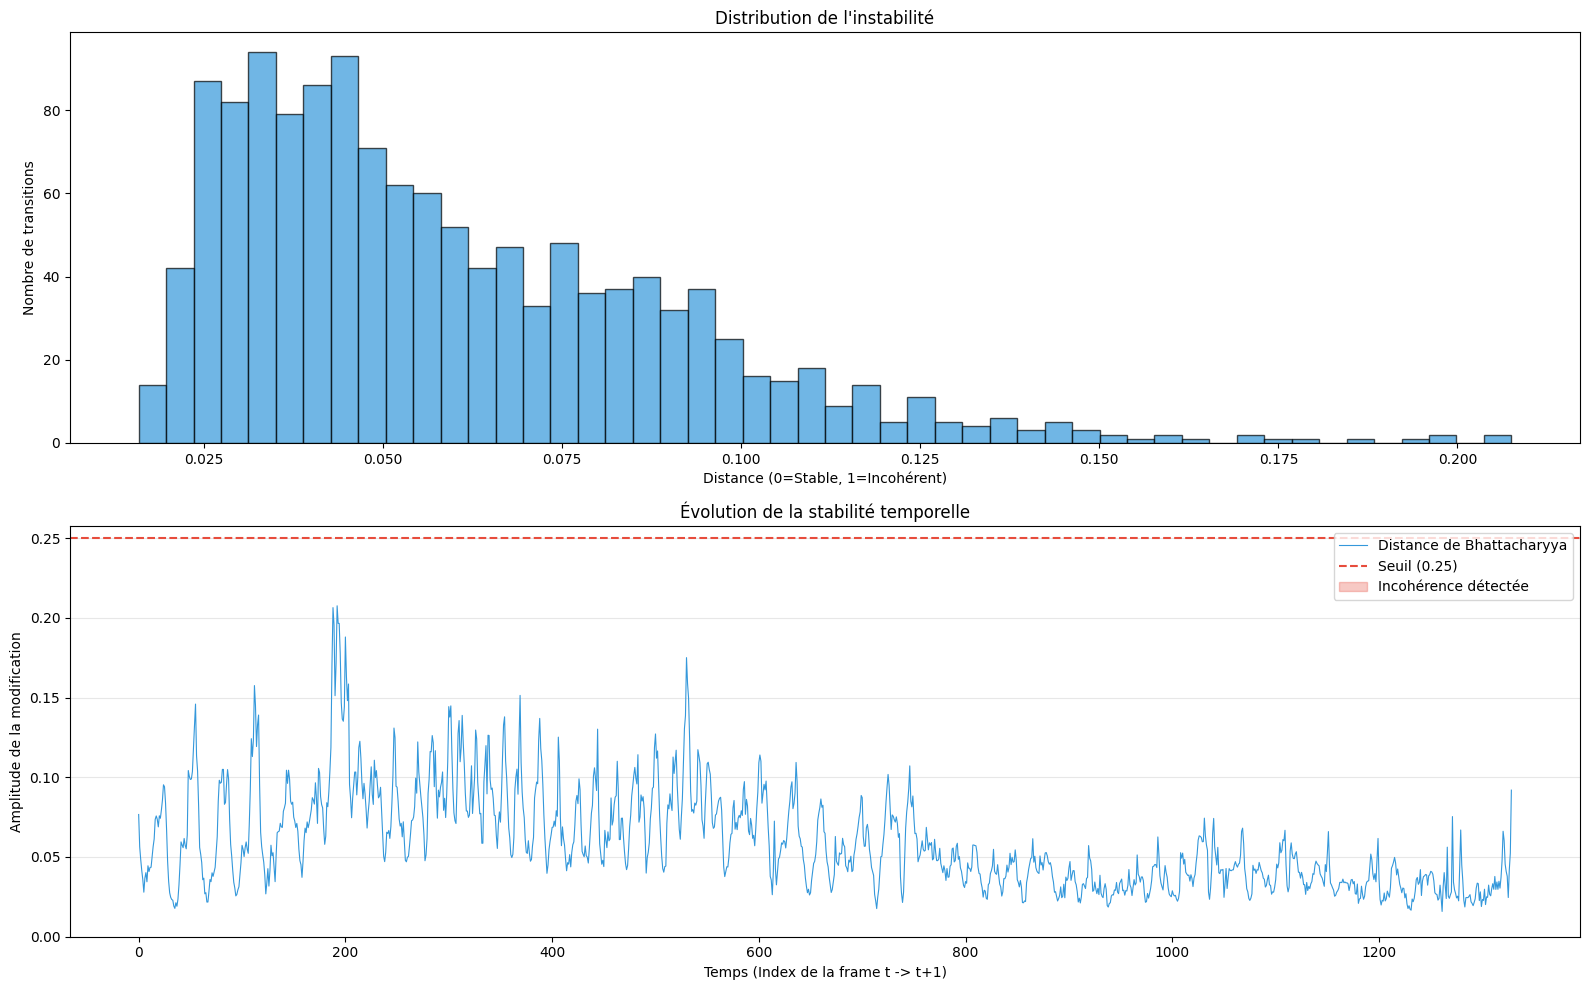

In [30]:
window_size_overlay = 2
distances_overlay, bad_frames_overlay = battacharrya_analysis_in_folder(MASKS_DIRECTORY, threshold, window_size_overlay)

In [31]:
frames_to_visualize = 15
visualize_top_anomalies(MASKS_DIRECTORY, distances_overlay, bad_frames_overlay, frames_to_visualize, window_size_overlay)

Nombre d'anomalies détectées : 0


#### D. Matrices de confusion

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

def load_annotations_csv(csv_path):
    """ Charge le CSV d'annotations (frame->label avec 1 pour ko et 0 pour ok dans label) """
    try:
        df = pd.read_csv(csv_path)
        df = df.sort_values(by='frame')
        print(f"Succès : {len(df)} frames annotées chargées.")
        return df['label'].values
    except Exception as e:
        print(f"Erreur lors du chargement du CSV : {e}")
        return None

def plot_confusion_matrix(y_true, bad_frames, total_frames):
    y_pred = np.ones(total_frames)
    y_pred[bad_frames] = 0

    # Synchronisation des longueurs
    min_len = min(len(y_true), len(y_pred))
    y_true_sync = y_true[:min_len]
    y_pred_sync = y_pred[:min_len]

    cm = confusion_matrix(y_true_sync, y_pred_sync, labels=[1, 0])

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu',
                xticklabels=['Prédit OK (1)', 'Prédit BUG (0)'],
                yticklabels=['Réel OK (1)', 'Réel BUG (0)'])
    plt.title('Matrice de Confusion')
    plt.ylabel('Vérité Terrain')
    plt.xlabel('Prédiction')
    plt.show()

    print(classification_report(y_true_sync, y_pred_sync, target_names=['BUG (0)', 'OK (1)']))

def plot_change_confusion_matrix(y_true, bad_frames):
    """ Matrice de confusion uniquement sur les changements d'états """
    total_frames = len(y_true)
    y_true_change = [0] * (total_frames - 1)
    y_pred_change = [0] * (total_frames - 1)

    for i in range(total_frames - 1):
        if y_true[i] != y_true[i+1]:
            y_true_change[i] = 1

    for index in bad_frames:
        y_pred_change[index] = 1

    y_true_final = np.array(y_true_change)
    y_pred_final = np.array(y_pred_change)

    # 4. Matrice de Confusion 2x2
    # labels=[0, 1] pour avoir Stable (0) en premier et Changement (1) en deuxième
    cm = confusion_matrix(y_true_final, y_pred_final, labels=[0, 1])

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
                xticklabels=['Stable (0)', 'Alerte (1)'],
                yticklabels=['Stable (0)', 'Changement (1)'])

    plt.title('Matrice de Confusion : Événements (Changement = 1)')
    plt.ylabel('Vérité Terrain (Humain)')
    plt.xlabel('Prédiction (Algorithme)')
    plt.show()
    print(classification_report(y_true_final, y_pred_final, target_names=['STABLE (0)', 'CHANGEMENT (1)']))

Succès : 1329 frames annotées chargées.
Méthode SANS overlay


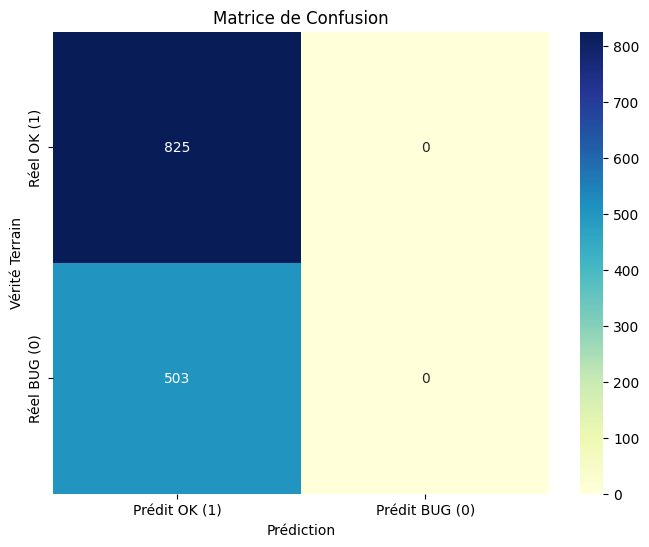

              precision    recall  f1-score   support

     BUG (0)       0.00      0.00      0.00       503
      OK (1)       0.62      1.00      0.77       825

    accuracy                           0.62      1328
   macro avg       0.31      0.50      0.38      1328
weighted avg       0.39      0.62      0.48      1328

Méthode AVEC overlay


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


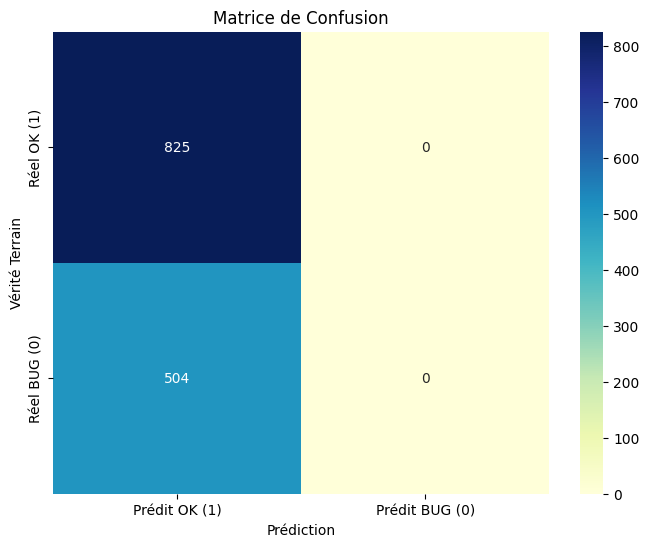

              precision    recall  f1-score   support

     BUG (0)       0.00      0.00      0.00       504
      OK (1)       0.62      1.00      0.77       825

    accuracy                           0.62      1329
   macro avg       0.31      0.50      0.38      1329
weighted avg       0.39      0.62      0.48      1329



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [33]:
ground_truth = load_annotations_csv(ANNOTATIONS_PATH)
if ground_truth is not None:
    print("Méthode SANS overlay")
    plot_confusion_matrix(ground_truth, bad_frames_simple, len(distances_simple))

    print("Méthode AVEC overlay")
    plot_confusion_matrix(ground_truth, bad_frames_overlay, len(distances_overlay))

Succès : 1329 frames annotées chargées.
Méthode SANS overlay


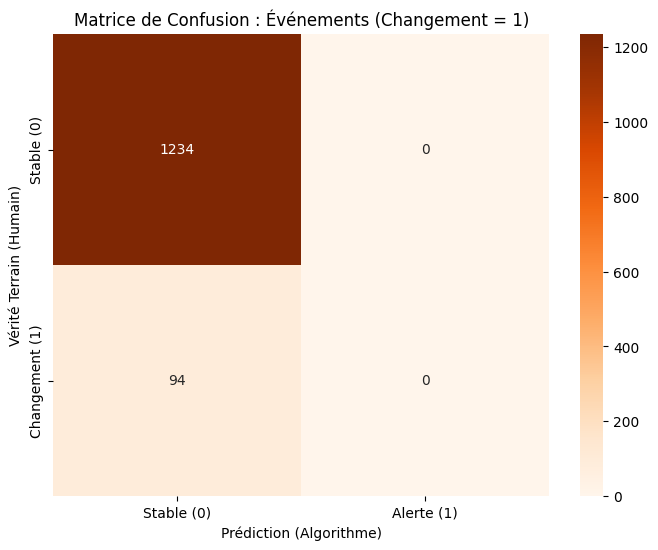

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                precision    recall  f1-score   support

    STABLE (0)       0.93      1.00      0.96      1234
CHANGEMENT (1)       0.00      0.00      0.00        94

      accuracy                           0.93      1328
     macro avg       0.46      0.50      0.48      1328
  weighted avg       0.86      0.93      0.90      1328


Méthode AVEC overlay


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


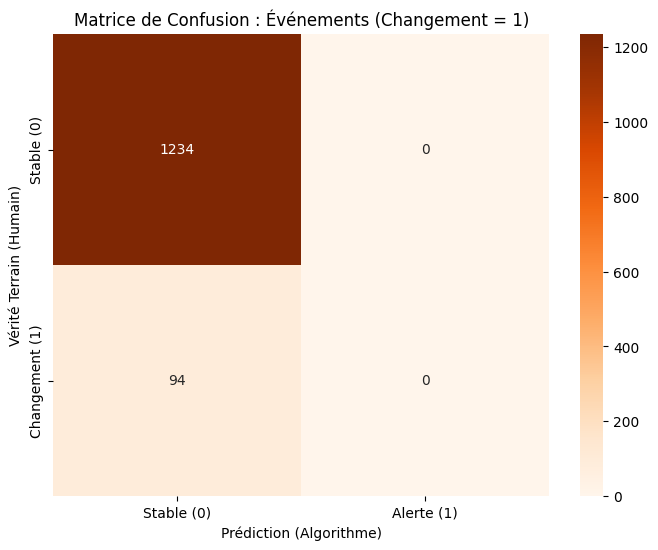

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                precision    recall  f1-score   support

    STABLE (0)       0.93      1.00      0.96      1234
CHANGEMENT (1)       0.00      0.00      0.00        94

      accuracy                           0.93      1328
     macro avg       0.46      0.50      0.48      1328
  weighted avg       0.86      0.93      0.90      1328



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [34]:
ground_truth = load_annotations_csv(ANNOTATIONS_PATH)
if ground_truth is not None:
    print("Méthode SANS overlay")
    plot_change_confusion_matrix(ground_truth, bad_frames_simple)

    print("\nMéthode AVEC overlay")
    plot_change_confusion_matrix(ground_truth, bad_frames_overlay)

### 3. Métrique : variation du squelette via `SAM 3D Body`

...

In [35]:
raise NotImplementedError("Implémtenter la variation du squelette avec SAM 3D Body depuis la V3.")

NotImplementedError: Implémtenter la variation du squelette avec SAM 3D Body depuis la V3.

### 4. Métrique : Groupes de pixels et distances

...

In [ ]:
...

### 5. Calcul de la fonction de score final

...

In [ ]:
...

---

## VII. Conclusion

Nous avons encore 2 problèmes :
- Les cheuveux de la danseuses ne sont pas tous les temps inclus dans le découpage, il faudra trouver une logique pour les inclure.
  - On pourrait explorer de nouveaux prompts en demandant explicitement d'inclure des cheveux.
- La méthode de replacement de la danseuse est fonctionnelle mais fastidieuse (calcul à la main des points). De plus, elle ne marche que dans le cadre des vidéos de pole dance.
  - Il faudrait donc trouver une méthode "plus générale et plus automatique" pour correctement replacer la danseuse.